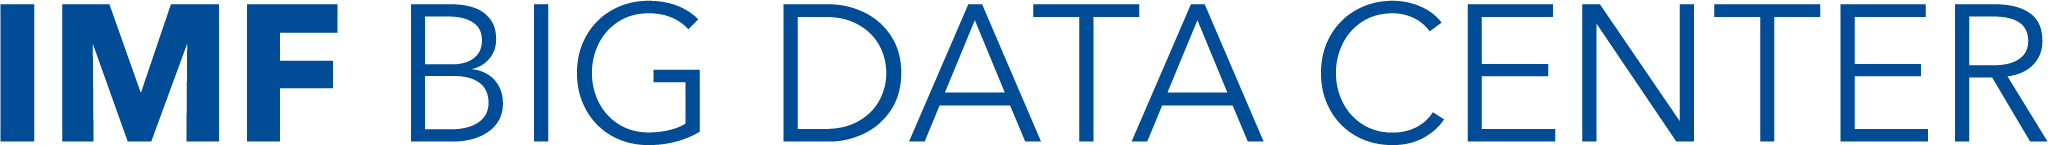

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/AlessandraSozzi/BDC_STI_26/blob/main/notebooks/BDC_NTLs_Analysis.ipynb)

# Nighttime Lights Data Exploration and Analysis

---

<br>**Contributors:** [Dharana Rijal](drijal@imf.org), [Alberto Sanchez](asanchez3@imf.org)
<br> **Last update:** 2025-10-23 (Created: 2025-May)
<br> **Description:** This notebook explores methods to work with nighttime lights for a given country
<br> **References:**

## Set-up

Mount Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Import Libraries

In [ ]:
import ee
import geemap
!pip install requests # Install requests library
import requests
from io import BytesIO
from PIL import Image
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.patches as mpatches
import pandas as pd
import numpy as np
import geopandas as gpd
from matplotlib.colors import ListedColormap, Normalize
import matplotlib.colorbar as cbar
import matplotlib.image as mpimg
from datetime import datetime
import os



### Define scope

Country of interest

In [ ]:
CountryName="Armenia"
CountryCode="ARM"

# country_codes = {
#     "Turkey": "TUR",
#     "Armenia": "ARM",
#     "Kazakhstan": "KAZ",
#     "Czech Republic": "CZE",
#     "Lithuania": "LTU",
#     "Romania": "ROU",
#     "Albania": "ALB",
#     "Austria": "AUT",
#     "Moldova": "MDA",
#     "Canada": "CAN",
#     "Bulgaria": "BGR",
#     "United Kingdom": "GBR",
#     "Mongolia": "MNG",
#     "Republic of Azerbaijan": "AZE",
#     "Uzbekistan": "UZB",
#     "Georgia": "GEO",
#     "Slovenia": "SVN",
#     "Slovak Republic": "SVK"
# }

Time range

In [ ]:
startYear = 2010
endYear = 2025

### Authenticate to GEE

⏰**Enter your Google Cloud project name**

In [ ]:
ee.Authenticate()
my_project_name = 'ee-bigdatacenter-1' # USE YOUR OWN GOOGLE CLOUD PROJECT
ee.Initialize(project=my_project_name)

### Retrive country boundaries

In [ ]:
# lat, long coordinates to center the map
countryCoords = [40.19, 44.51]

# GADM GeoJson. Explore gadm for the different layers (from 0 to 4): https://geodata.ucdavis.edu/gadm/gadm4.1/json/
countryBoundaries = f'https://geodata.ucdavis.edu/gadm/gadm4.1/json/gadm41_{CountryCode}_1.json'

# Fetch GeoJSON data from the URL
response = requests.get(countryBoundaries)
geo_json_data = response.json() # Convert response to a Python dictionary

In [ ]:
print(type(geo_json_data))
print(geo_json_data.keys())
print(geo_json_data['features'][0])

<class 'dict'>
dict_keys(['type', 'name', 'crs', 'features'])
{'type': 'Feature', 'properties': {'GID_1': 'ARM.1_1', 'GID_0': 'ARM', 'COUNTRY': 'Armenia', 'NAME_1': 'Aragatsotn', 'VARNAME_1': "Aragacot'n", 'NL_NAME_1': 'Արագածոտն|Арагацотн', 'TYPE_1': 'Marz', 'ENGTYPE_1': 'Province', 'CC_1': 'NA', 'HASC_1': 'AM.AG', 'ISO_1': 'NA'}, 'geometry': {'type': 'MultiPolygon', 'coordinates': [[[[44.4391, 40.2596], [44.4186, 40.2328], [44.4186, 40.2183], [44.4019, 40.2203], [44.3839, 40.2289], [44.3044, 40.252], [44.2813, 40.2742], [44.2753, 40.2768], [44.2694, 40.2751], [44.2403, 40.2486], [44.2275, 40.2434], [44.2155, 40.2434], [44.2001, 40.2486], [44.195, 40.2546], [44.1924, 40.2605], [44.1838, 40.2648], [44.1744, 40.2622], [44.1744, 40.2494], [44.1796, 40.2007], [44.1676, 40.1938], [44.0778, 40.1956], [44.0479, 40.2024], [43.9846, 40.2109], [43.9427, 40.2212], [43.9213, 40.2238], [43.9034, 40.2238], [43.8598, 40.2511], [43.8469, 40.2537], [43.8444, 40.2605], [43.8444, 40.2682], [43.8333, 40.

### Helper functions

In [ ]:
# Define study area (Selected_country) and admin levels
def get_Selected_country_boundary():
    """s
    Fetches the geometry for Selected_country from GADM
    """
    # See above geo_json_data description
    Selected_country = ee.FeatureCollection(geo_json_data).filter(ee.Filter.eq('GID_0', CountryCode))
    #dataset = ee.FeatureCollection("FAO/GAUL/2015/level0")
    # Selected_country = dataset.filter(ee.Filter.eq("ADM0_NAME", country))
    return Selected_country # returns a FeatureCollection representing the boundary of the country specified


# Define a time range and calculate the median NTL for the study area
def get_NTL_time_series(start_date, end_date, region):
    """
    Fetches the NTL data within a specific date range and region, then computes the median.
    """
    filtered_NTL = NTL_dataset.filterDate(start_date, end_date).filterBounds(region)
    return filtered_NTL.median().clip(region)


# Generate the thumbnail URL with a suitable NTL color palette
def generate_ntl_thumbnail(start_date, end_date, region):
    """
    Generates a thumbnail image URL for NTL data between the given time period.
    """
    mean_NTL = get_NTL_time_series(start_date, end_date, region)
    url = mean_NTL.getThumbURL({
        'min': 0,  # Minimum value of NTL
        'max': 50,  # Maximum value of NTL (adjust as needed)
        'palette': '000000,0000FF,00FFFF,FFFF00,FF0000,FFFFFF',  # Blue to red color palette
        'dimensions': 512,
        'region': region.geometry().bounds().getInfo()  # Use the bounding box of the region
    })
    return url

# Get the median NTL for specific years
def get_NTL_median(year, region):
    """
    Fetches the median NTL for a specific year and region.
    """
    start_date = f"{year}-01-01"
    end_date = f"{year}-12-31"
    filtered_NTL = NTL_dataset.filterDate(start_date, end_date).filterBounds(region)
    return filtered_NTL.median().clip(region)

# Step 4: Calculate the difference and classify changes
def classify_NTL_changes(image_1, image_2):
    """
    Classifies changes between two NTL images into New Lights, Lost Lights, and No Change.
    """
    diff = image_1.subtract(image_2) # ee.Image showing the raw difference (w/ each pixel represents the difference)

    # Define thresholds for changes
    new_lights = diff.gt(5)  # New Lights: Increase > 5 # # ee.Image (mask layer!) with 1 where condition met, 0 elsewhere
    lost_lights = diff.lt(-5)  # Lost Lights: Decrease < -5
    no_change = diff.gte(-5).And(diff.lte(5))  # No Change: Between -5 and 5

    # Combine all into one image
    classified = (new_lights.multiply(1)
                  .add(lost_lights.multiply(2))
                  .add(no_change.multiply(3)))
    return classified # ee.Image object that overlays the three classes, allowing visualization in a single map

# Calculate the percentage change in light between 2013 and 2023
def calculate_percentage_change(image_1, image_2):
    """
    Calculate the percentage change in NTL between two images.
    """
    # Avoid division by zero by replacing zero values with 1
    safe_image_1 = image_1.where(image_1.eq(0), ee.Number(1))
    percentage_change = image_2.subtract(image_1).divide(safe_image_1).multiply(100)
    return percentage_change

# Fetch yearly mean NTL for a region
def get_yearly_mean_NTL(year, geometry, NTL_dataset):
    start_date = ee.Date(f'{year}-01-01')
    end_date = start_date.advance(1, 'year')
    NTL_image = NTL_dataset.filterDate(start_date, end_date).filterBounds(geometry)
    temporalReducer = ee.Reducer.mean()
    stats = NTL_image.select("Gap_Filled_DNB_BRDF_Corrected_NTL").reduce(temporalReducer)

    # Reduce the image to get mean NTL for the year
    mean_NTL = stats.reduceRegion(
        reducer=ee.Reducer.mean(),
        geometry=geometry,
        scale=500,
        maxPixels=1e9
    ).get('Gap_Filled_DNB_BRDF_Corrected_NTL_mean')

    return mean_NTL.getInfo()

# Fetch NTL for a specific date range
def get_NTL_for_date(date, geometry, NTL_dataset):
    start_date = ee.Date(date.strftime('%Y-%m-%d'))
    end_date = start_date.advance(1, 'month')
    NTL_image = NTL_dataset.filterDate(start_date, end_date).filterBounds(geometry)
    temporalReducer = ee.Reducer.mean()
    stats = NTL_image.select("Gap_Filled_DNB_BRDF_Corrected_NTL").reduce(temporalReducer)

    # Reduce the image to get mean and sum NTL
    mean_NTL = stats.reduceRegion(
        reducer=ee.Reducer.mean(),
        geometry=geometry,
        scale=1000,
        maxPixels=1e9
    ).get('Gap_Filled_DNB_BRDF_Corrected_NTL_mean')

    sum_NTL = stats.reduceRegion(
        reducer=ee.Reducer.sum(),
        geometry=geometry,
        scale=5000,
        maxPixels=1e9
    ).get('Gap_Filled_DNB_BRDF_Corrected_NTL_mean')

    return mean_NTL.getInfo(), sum_NTL.getInfo()



## **Display NTLs on a map**

**Display median NTL values**

The following calculates and displays median NTL values with a color-coded representation, where brighter colors indicate higher light intensity (urban or economically active areas) and darker colors show lower intensity (rural or less developed regions). The map includes a dynamic title with the country name and a color bar for interpreting NTL values

Explore Bands available: https://developers.google.com/earth-engine/datasets/catalog/NASA_VIIRS_002_VNP46A2

### Define NTL dataset

In [ ]:
# useful for econ activity, urbanization, electricity access
NTL_dataset = ee.ImageCollection("NASA/VIIRS/002/VNP46A2").select("Gap_Filled_DNB_BRDF_Corrected_NTL")

### Country level

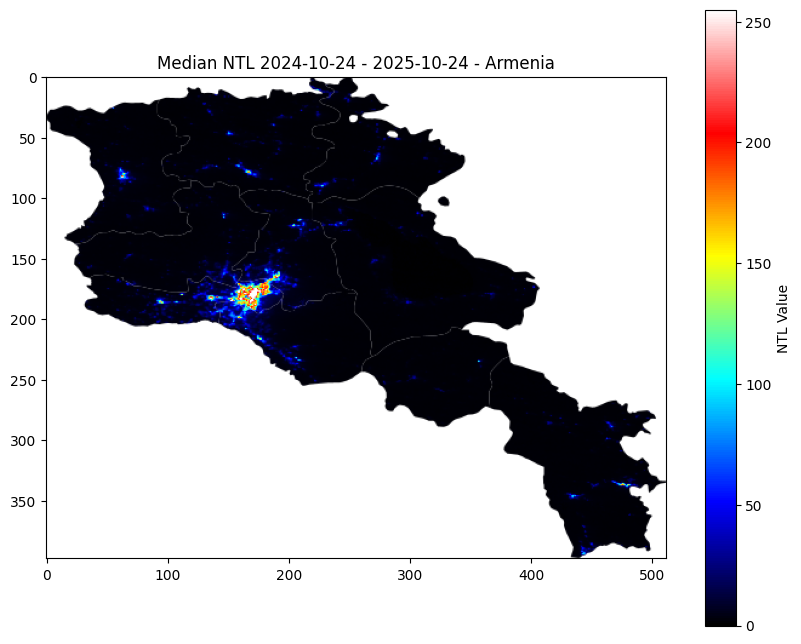

In [ ]:
# Fetch boundaries for Selected_country
Selected_country = get_Selected_country_boundary()

# Define start and end dates
start_date = "2024-10-24"
end_date = "2025-10-24"

# Get median NTL for the study area
median_NTL = get_NTL_time_series(start_date, end_date, Selected_country)

# Generate the thumbnail URL with a suitable NTL color palette
url = median_NTL.getThumbURL({
    'min': 0,  # Minimum value of NTL
    'max': 50,  # Maximum value of NTL (adjust as needed)
    'palette': '000000,0000FF,00FFFF,FFFF00,FF0000,FFFFFF',  # Blue to red color palette
    'dimensions': 512,
    'region': Selected_country.geometry().bounds().getInfo()  # Use the bounding box of Selected_country as the region
})

# Download the thumbnail image
response = requests.get(url)
img = Image.open(BytesIO(response.content))

# Custom Matplotlib colormap matching GEE palette
colors = ['#000000', '#0000FF', '#00FFFF', '#FFFF00', '#FF0000', '#FFFFFF']
cmap = LinearSegmentedColormap.from_list("custom_palette", colors, N=256)


# Plot the NTL image using Matplotlib
plt.figure(figsize=(10, 8))
plt.imshow(img, cmap=cmap, origin="upper")  # Using 'hot' colormap for better brightness contrast
plt.colorbar(label="NTL Value")
plt.title("Median NTL " + start_date + " - " + end_date + " - " + CountryName)
plt.show()


### Side-by-side

The following produces a side-by-side comparison of nighttime light (NTL) intensity maps for two different years for a specified country. It calculates the median NTL values within the selected country's boundaries for each year and generates thumbnail images with a blue-to-red color palette to represent varying light intensities. Brighter colors indicate higher light emissions, while darker colors signify lower emission

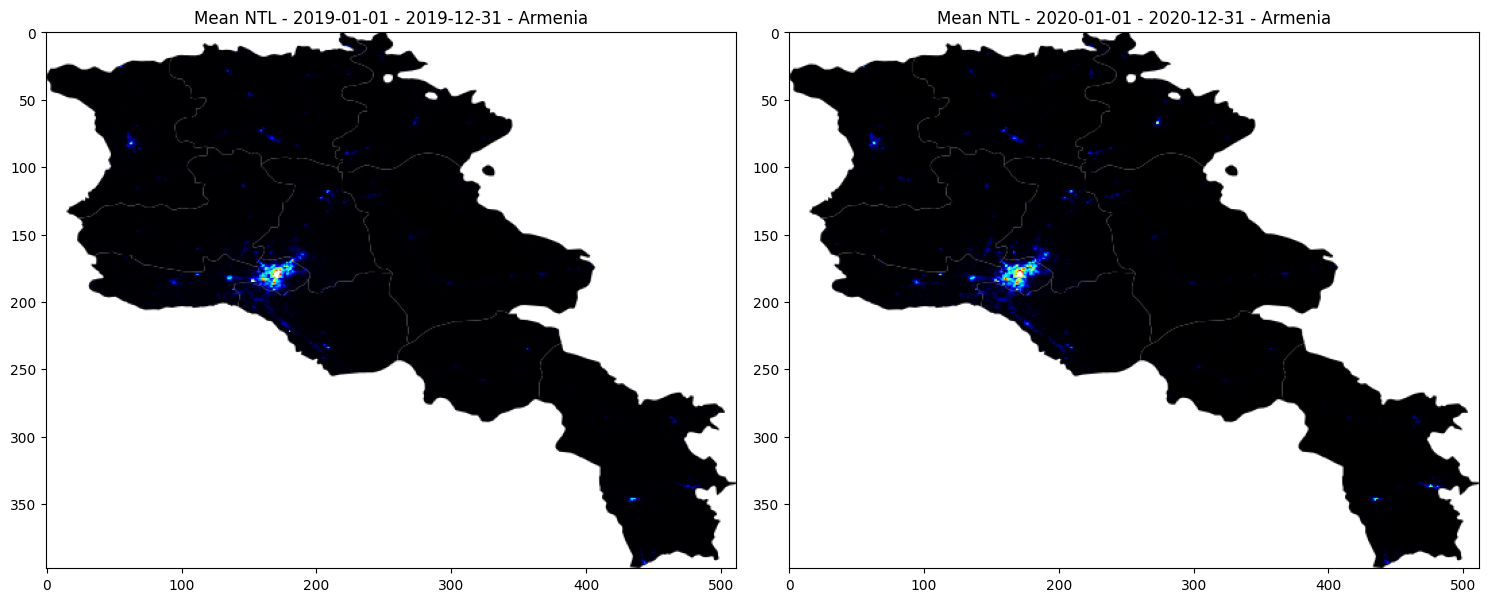

In [ ]:
# Define start and end dates
start_date1 = "2019-01-01"
end_date1 = "2019-12-31"
start_date2 = "2020-01-01"
end_date2 = "2020-12-31"

# Fetch boundaries for Selected_country
Selected_country = get_Selected_country_boundary()

# Fetch two sets of NTL data:
url_start = generate_ntl_thumbnail(start_date1, end_date1, Selected_country)
url_end = generate_ntl_thumbnail(start_date2, end_date2, Selected_country)

# Download the two thumbnail images
response_start = requests.get(url_start)
img_start = Image.open(BytesIO(response_start.content))

response_end = requests.get(url_end)
img_end = Image.open(BytesIO(response_end.content))

# Plot the NTL images side by side to compare the two years
fig, axes = plt.subplots(1, 2, figsize=(15, 8))

# Plot the start image
axes[0].imshow(img_start, cmap="hot", origin="upper")
axes[0].set_title("Mean NTL - " + start_date1 + " - " + end_date1 + " - " + CountryName)
# axes[0].colorbar(label="NTL Value")

# Plot the end image
axes[1].imshow(img_end, cmap="hot", origin="upper")
axes[1].set_title("Mean NTL - " + start_date2 + " - " + end_date2 + " - " + CountryName)
# axes[1].colorbar(label="NTL Value")

plt.tight_layout()
plt.show()



### Change in Nighttime light at pixel levels

The following generates a visual representation of changes in nighttime light (NTL) intensity between two years for a specified country.It calculates the median NTL values for each year and identifies areas with significant increases ("New light"), decreases ("Lost Light"), or no change in light emissions. These changes are classified into three categories and displayed on a map using a color-coded scheme: blue for new light, red for lost light, and green for no change.

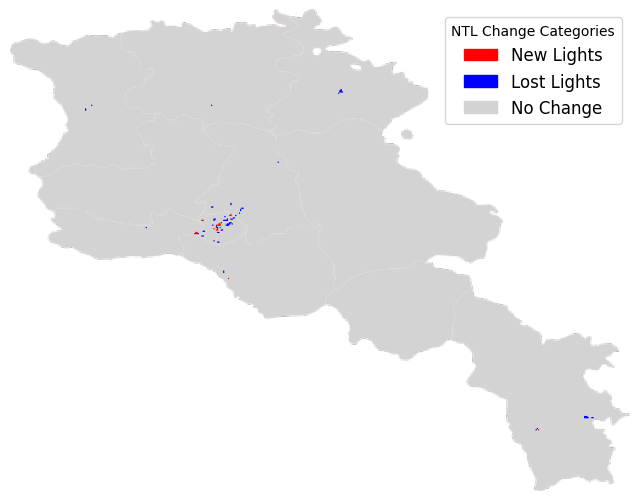

In [ ]:
# Fetch boundaries for Selected_country
Selected_country = get_Selected_country_boundary()

# reference years
start_date = 2019
end_date = 2020

# Get median NTL for two reference years
NTL_start = get_NTL_median(start_date, Selected_country) # ee.Image
NTL_end = get_NTL_median(end_date, Selected_country) # ee.Image

# Classify changes
NTL_changes = classify_NTL_changes(NTL_end, NTL_start)

# Get Thumbnail URL for the classified NTL changes with a region specified
thumbnail_url = NTL_changes.getThumbURL({
    'min': 1,
    'max': 3,
    'palette': ['blue', 'red', '#d3d3d3'],
    'dimensions': 512,
    'region': Selected_country.geometry().bounds().getInfo()  # Specify the region (Selected_country boundary)
})

# Download the thumbnail and display it using matplotlib
response = requests.get(thumbnail_url)
img = Image.open(BytesIO(response.content))

# Display the image with matplotlib
fig, ax = plt.subplots(figsize=(8, 8))
ax.imshow(img)
ax.axis('off')  # Hide axes

# Add the legend
legend_labels = ['New Lights', 'Lost Lights', 'No Change']
legend_colors = ['red', 'blue', '#d3d3d3']
handles = [mpatches.Patch(color=color, label=label) for color, label in zip(legend_colors, legend_labels)]

ax.legend(handles=handles, loc='upper right', fontsize=12, title="NTL Change Categories")

plt.show()


The following produces the visual representation of the percentage change in nighttime light (NTL) intensity between 2013 and 2024 for a specified country.It calculates the median NTL values for both years and computes the percentage change between them. Areas with increased light intensity are displayed in red, while areas with decreased intensity appear in blue, and regions with no significant change are shown in white.

The resulting visualization is a map that highlights spatial patterns of NTL changes within the country's boundaries. The map is generated as a thumbnail image and displayed , with a horizontal color bar indicating the percentage change scale (-100% to +100%).

/tmp/ipython-input-3974688926.py:36: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('bwr')  # Blue-White-Red colormap


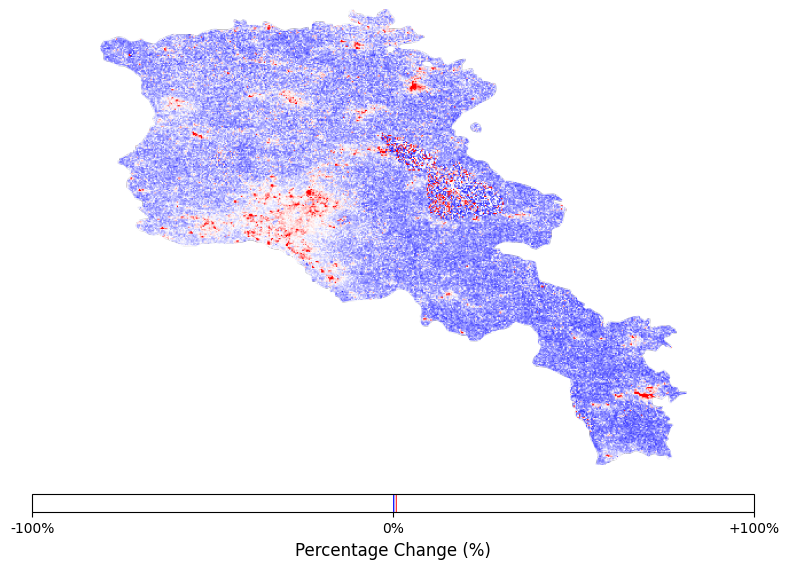

In [ ]:
# Fetch boundaries for Selected_country
Selected_country = get_Selected_country_boundary()

# Calculate the percentage change in light
percentage_change = calculate_percentage_change(NTL_start, NTL_end)

# Get Thumbnail URL for the percentage change
thumbnail_params = {
    'min': -100,  # Minimum value for percentage change
    'max': 100,   # Maximum value for percentage change
    'palette': ['blue', 'white', 'red'],  # Color ramp with white for no change
    'dimensions': 512,
    'region': {  # Ensure it's a valid GeoJSON dictionary
        "type": "Polygon",
        "coordinates": Selected_country.bounds().getInfo()['coordinates']
    }
}

try:
    thumbnail_url_percentage_change = percentage_change.getThumbURL(thumbnail_params)
except Exception as e:
    print(f"Error generating thumbnail URL: {e}")
    thumbnail_url_percentage_change = None

if thumbnail_url_percentage_change:
    # Step 6: Download the thumbnail and display it using matplotlib
    response = requests.get(thumbnail_url_percentage_change)
    img = Image.open(BytesIO(response.content))

    # Display the image with matplotlib
    fig, ax = plt.subplots(figsize=(8, 6))
    ax.imshow(img)
    ax.axis('off')  # Hide axes

    # Add horizontal color bar
    cmap = plt.cm.get_cmap('bwr')  # Blue-White-Red colormap
    norm = plt.Normalize(vmin=-100, vmax=100)

    cbar = fig.colorbar(
        plt.cm.ScalarMappable(cmap=cmap,
                              #norm=norm
                              ),
        ax=ax,
        orientation='horizontal',
        pad=0.05,  # Adjust padding for better alignment
        aspect=40  # Control the width of the color bar
    )
    cbar.set_label('Percentage Change (%)', fontsize=12)
    cbar.ax.tick_params(labelsize=10)  # Set tick label size
    cbar.set_ticks([-100, 0, 100])  # Explicitly set ticks for clarity
    cbar.set_ticklabels(['-100%', '0%', '+100%'])  # Label the ticks

    # Add the legend (optional)
    legend_labels = ['Decrease (-100%)', 'No Change (0%)', 'Increase (+100%)']
    legend_colors = ['blue', 'white', 'red']
    handles = [mpatches.Patch(color=color, label=label) for color, label in zip(legend_colors, legend_labels)]

    plt.tight_layout()
    plt.show()
else:
    print("Failed to generate thumbnail URL.")


## **Change in Nighttime light at different ADM levels**
Ignore all the below as there is no data in lower admin levels for selected countries, that is, only Admin 0 (country level) is available.

### Compute NTL for Admin 1 level

This calculates and analyzes yearly mean nighttime light (NTL) intensity for administrative regions (Admin 1 level) within a specified country the dataset.

In [ ]:
# Fetch Admin 1 boundaries for Selected_country
Selected_country_Admin1 = ee.FeatureCollection(geo_json_data).filter(ee.Filter.eq('GID_0', CountryCode))
regions = Selected_country_Admin1.toList(Selected_country_Admin1.size()).getInfo()

⚠ This may take a while depending on the number of Admin 1 regions in selected country

In [ ]:
# Process each region to calculate yearly mean NTL
years = range(2013, 2025)
results = []

for region in regions:
    region_name = region['properties']['NAME_1'] # Use 'NAME_1' for Admin 1 name in GADM data
    print(f"Processing NTL data for Admin 1: {region_name}")

    geometry = ee.Geometry(region['geometry'])
    yearly_data = {"ADM1_NAME": region_name}

    for year in years:
        try:
            mean_NTL = get_yearly_mean_NTL(year, geometry, NTL_dataset)
            yearly_data[year] = mean_NTL
        except Exception as e:
            print(f"Error for {region_name} in {year}: {e}")
            yearly_data[year] = None

    results.append(yearly_data)

# Create a DataFrame
df = pd.DataFrame(results)

# Calculate percentage changes between years
for year in years:
    if year != years[0]:  # Skip the first year
        previous_year = year - 1
        df[f'Pct_Change_{previous_year}_{year}'] = (
            (df[year] - df[previous_year]) / df[previous_year] * 100
        )

# Save to CSV
df.to_csv("Yearly_NTL_Percentage_Changes.csv", index=False)
print("Saved yearly mean NTL data with percentage changes to 'Yearly_NTL_Percentage_Changes.csv'.")

# Display the DataFrame
print(df)

Processing NTL data for Admin 1: Aragatsotn
Processing NTL data for Admin 1: Ararat
Processing NTL data for Admin 1: Armavir
Processing NTL data for Admin 1: Erevan
Processing NTL data for Admin 1: Gegharkunik
Processing NTL data for Admin 1: Kotayk
Processing NTL data for Admin 1: Lori
Processing NTL data for Admin 1: Shirak
Processing NTL data for Admin 1: Syunik
Processing NTL data for Admin 1: Tavush
Processing NTL data for Admin 1: VayotsDzor
Saved yearly mean NTL data with percentage changes to 'Yearly_NTL_Percentage_Changes.csv'.
      ADM1_NAME       2013      2014      2015      2016      2017      2018  \
0    Aragatsotn   0.334487  0.324116  0.310308  0.296639  0.330274  0.283586   
1        Ararat   0.576965  0.563379  0.512720  0.478859  0.527099  0.509372   
2       Armavir   0.874617  0.768215  0.708667  0.687857  0.775969  0.723562   
3        Erevan  10.045682  9.526252  9.398964  9.578830  9.288498  8.968407   
4   Gegharkunik   0.291082  0.289856  0.273851  0.266580 

In [ ]:
# Calculate percentage changes between years
for year in years:
    if year != years[0]:  # Skip the first year
        previous_year = year - 1
        df[f'Pct_Change_{previous_year}_{year}'] = (
            (df[year] - df[previous_year]) / df[previous_year] * 100
        )

# Save to CSV
df.to_csv("Yearly_NTL_Percentage_Changes.csv", index=False)
print("Saved yearly mean NTL data with percentage changes to 'Yearly_NTL_Percentage_Changes.csv'.")

# Display the DataFrame
print(df)

Saved yearly mean NTL data with percentage changes to 'Yearly_NTL_Percentage_Changes.csv'.
      ADM1_NAME       2013      2014      2015      2016      2017      2018  \
0    Aragatsotn   0.334487  0.324116  0.310308  0.296639  0.330274  0.283586   
1        Ararat   0.576965  0.563379  0.512720  0.478859  0.527099  0.509372   
2       Armavir   0.874617  0.768215  0.708667  0.687857  0.775969  0.723562   
3        Erevan  10.045682  9.526252  9.398964  9.578830  9.288498  8.968407   
4   Gegharkunik   0.291082  0.289856  0.273851  0.266580  0.300074  0.233466   
5        Kotayk   0.709566  0.848325  0.663472  0.826950  1.037948  1.020598   
6          Lori   0.345838  0.342988  0.326661  0.314529  0.344968  0.272825   
7        Shirak   0.370317  0.346006  0.329258  0.326823  0.357695  0.302419   
8        Syunik   0.320520  0.329517  0.314305  0.297330  0.333659  0.276573   
9        Tavush   0.330771  0.330240  0.318384  0.299157  0.336923  0.259289   
10   VayotsDzor   0.299799  0

### Visualize NTLs at Admin 1 level.

In this generated df, positive changes are displayed with a light green background, negative changes with a light coral background, and no change is shown with a white background.

In [ ]:
# Read the saved CSV file
df = pd.read_csv("Yearly_NTL_Percentage_Changes.csv")

# Define a function to apply color formatting based on values
def highlight_changes(val):
    """
    Highlight cells in green for positive values and red for negative values.
    """
    if pd.isna(val):  # Handle NaN values
        return ''
    if val > 0:
        return 'background-color: lightgreen; color: black;'
    elif val < 0:
        return 'background-color: lightcoral; color: black;'
    else:
        return 'background-color: white; color: black;'

# Select only the percentage change columns
change_columns = [col for col in df.columns if col.startswith("Pct_Change_")]

# Apply styling to the DataFrame
styled_df = df.style.applymap(highlight_changes, subset=change_columns)

# Display the styled DataFrame in the notebook (for Jupyter users)
styled_df


/tmp/ipython-input-3073535936.py:22: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  styled_df = df.style.applymap(highlight_changes, subset=change_columns)


,ADM1_NAME,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,Pct_Change_2013_2014,Pct_Change_2014_2015,Pct_Change_2015_2016,Pct_Change_2016_2017,Pct_Change_2017_2018,Pct_Change_2018_2019,Pct_Change_2019_2020,Pct_Change_2020_2021,Pct_Change_2021_2022,Pct_Change_2022_2023,Pct_Change_2023_2024
0,Aragatsotn,0.334487,0.324116,0.310308,0.296639,0.330274,0.283586,0.315749,0.227188,0.292901,0.394977,0.493613,0.430056,-3.100693,-4.260171,-4.405142,11.339017,-14.136125,11.341398,-28.047835,28.924461,34.849901,24.972587,-12.875903
1,Ararat,0.576965,0.563379,0.512720,0.478859,0.527099,0.509372,0.597846,0.532117,0.715814,1.044655,0.981797,1.133132,-2.354804,-8.991979,-6.604144,10.073940,-3.363021,17.369156,-10.994248,34.521739,45.939522,-6.017126,15.414110
2,Armavir,0.874617,0.768215,0.708667,0.687857,0.775969,0.723562,0.845750,0.831180,1.026276,1.388895,1.734708,1.918074,-12.165560,-7.751406,-2.936482,12.809634,-6.753806,16.887069,-1.722781,23.472172,35.333510,24.898442,10.570424
3,Erevan,10.045682,9.526252,9.398964,9.578830,9.288498,8.968407,10.712333,12.097413,12.532552,15.419721,17.044474,22.247427,-5.170679,-1.336178,1.913676,-3.030975,-3.446099,19.445206,12.929776,3.596954,23.037363,10.536852,30.525746
4,Gegharkunik,0.291082,0.289856,0.273851,0.266580,0.300074,0.233466,0.255159,0.176879,0.211370,0.293566,0.369739,0.301147,-0.421222,-5.521734,-2.655169,12.564421,-22.197143,9.291485,-30.678816,19.499898,38.886984,25.947578,-18.551415
5,Kotayk,0.709566,0.848325,0.663472,0.826950,1.037948,1.020598,0.965251,0.900957,1.091814,1.354702,1.212011,1.247940,19.555550,-21.790423,24.639844,25.515281,-1.671578,-5.422994,-6.660922,21.183796,24.078146,-10.533022,2.964423
6,Lori,0.345838,0.342988,0.326661,0.314529,0.344968,0.272825,0.310152,0.234301,0.278640,0.372792,0.446981,0.389633,-0.824121,-4.760128,-3.714171,9.677782,-20.912942,13.681695,-24.456002,18.923724,33.789778,19.901152,-12.830069
7,Shirak,0.370317,0.346006,0.329258,0.326823,0.357695,0.302419,0.339484,0.255548,0.315561,0.404354,0.503030,0.428595,-6.564936,-4.840280,-0.739510,9.446009,-15.453443,12.256301,-24.724560,23.484071,28.138231,24.403176,-14.797363
8,Syunik,0.320520,0.329517,0.314305,0.297330,0.333659,0.276573,0.297283,0.236222,0.282288,0.365868,0.448118,0.394772,2.806758,-4.616198,-5.400866,12.218395,-17.109024,7.487934,-20.539712,19.501178,29.608248,22.480606,-11.904388
9,Tavush,0.330771,0.330240,0.318384,0.299157,0.336923,0.259289,0.301436,0.238962,0.285781,0.358110,0.443158,0.371153,-0.160555,-3.590070,-6.039006,12.624385,-23.042186,16.254880,-20.725404,19.592617,25.309098,23.749420,-16.248194


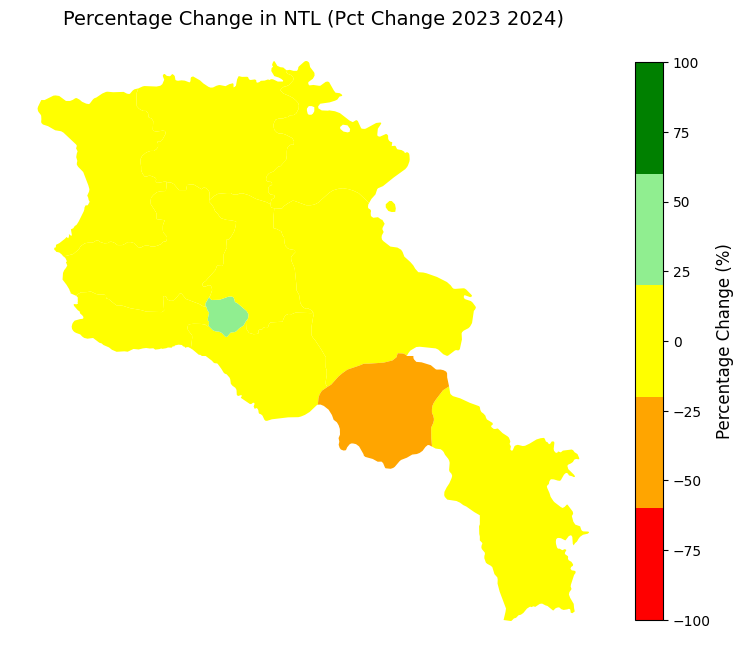

In [ ]:
# Convert Admin 1 boundaries to GeoJSON for GeoPandas
admin1_geojson = Selected_country_Admin1.getInfo()
admin1_gdf = gpd.GeoDataFrame.from_features(admin1_geojson['features'], crs="EPSG:4326")

# Read the yearly data with percentage changes
df = pd.read_csv("Yearly_NTL_Percentage_Changes.csv")

# Select the column for percentage change (e.g., Pct_Change_2022_2023)
selected_column = "Pct_Change_2023_2024"

# Merge the percentage change data with the GeoDataFrame
merged_gdf = admin1_gdf.merge(df[['ADM1_NAME', selected_column]], left_on='NAME_1', right_on='ADM1_NAME')

# Normalize the data for coloring
vmin, vmax = -100, 100
norm = Normalize(vmin=vmin, vmax=vmax)

# Define a custom color map (green to red)
cmap = ListedColormap(['red', 'orange', 'yellow', 'lightgreen', 'green'])

# Plot the map
fig, ax = plt.subplots(1, 1, figsize=(12, 8))
merged_gdf.plot(
    column=selected_column,
    cmap=cmap,
    norm=norm,
    ax=ax,
    legend=False
)
ax.set_title(f"Percentage Change in NTL ({selected_column.replace('_', ' ')})", fontsize=14)
ax.axis('off')

# Add the color ramp (legend) to the side
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, orientation="vertical", fraction=0.03, pad=0.02)
cbar.set_label("Percentage Change (%)", fontsize=12)

# Display the plot
plt.show()

The following visualizes percentage changes in nighttime light (NTL) intensity for administrative regions (Admin 1 level) of a specified country. It merges NTL percentage change data from a CSV file with geographic boundaries. It maps these changes onto a choropleth map, where colors represent the magnitude of change: red for decreases, green for increases, and intermediate hues for moderate changes.

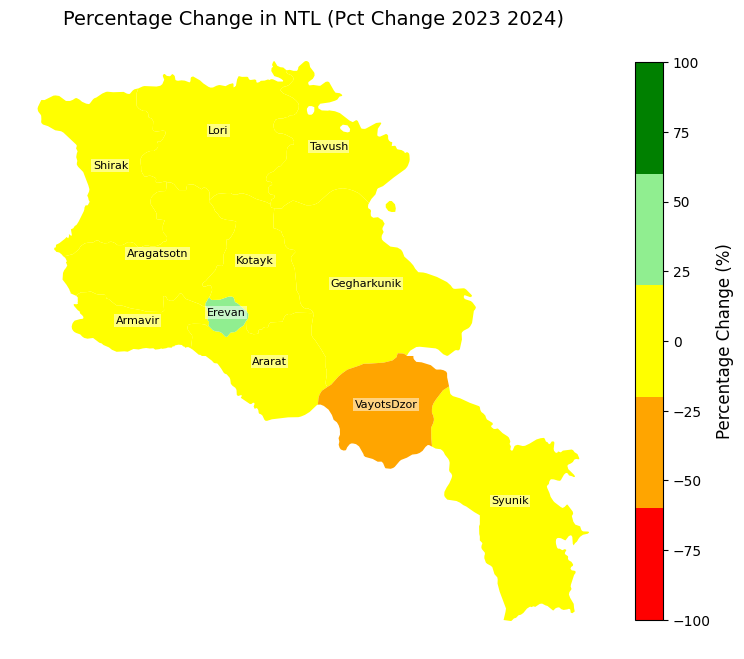

In [ ]:
# Convert Admin 1 boundaries to GeoJSON for GeoPandas
admin1_geojson = Selected_country_Admin1.getInfo()
admin1_gdf = gpd.GeoDataFrame.from_features(admin1_geojson['features'], crs="EPSG:4326")

# Read the yearly data with percentage changes
df = pd.read_csv("Yearly_NTL_Percentage_Changes.csv")

# Select the column for percentage change (e.g., Pct_Change_2022_2023)
selected_column = "Pct_Change_2023_2024"

# Merge the percentage change data with the GeoDataFrame
merged_gdf = admin1_gdf.merge(df[['ADM1_NAME', selected_column]], left_on='NAME_1', right_on='ADM1_NAME')

# Normalize the data for coloring
vmin, vmax = -100, 100
norm = Normalize(vmin=vmin, vmax=vmax)

# Define a custom color map (green to red)
cmap = ListedColormap(['red', 'orange', 'yellow', 'lightgreen', 'green'])

# Plot the map
fig, ax = plt.subplots(1, 1, figsize=(12, 8))
merged_gdf.plot(
    column=selected_column,
    cmap=cmap,
    norm=norm,
    ax=ax,
    legend=False
)
ax.set_title(f"Percentage Change in NTL ({selected_column.replace('_', ' ')})", fontsize=14)
ax.axis('off')

# Add labels (names of Admin1 regions)
for _, row in merged_gdf.iterrows():
    # Get the centroid of each geometry
    centroid = row['geometry'].centroid
    # Add text with the Admin1 name
    ax.text(
        centroid.x,
        centroid.y,
        row['ADM1_NAME'],
        fontsize=8,
        ha='center',
        color='black',
        bbox=dict(facecolor='white', alpha=0.5, edgecolor='none', pad=1)
    )

# Add the color ramp (legend) to the side
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, orientation="vertical", fraction=0.03, pad=0.02)
cbar.set_label("Percentage Change (%)", fontsize=12)

# Display the plot
plt.show()


### Plot NTLs time series by Admin 1 level

The folowing visualizes nighttime light (NTL) data for administrative regions (Admin 1 level) of a specified country over the whole time series. Calculates mean and sum values for each region

⚠ This may take a while depending on the number of Admin 1 regions in selected country

Processing NTL data for Admin 1: Aragatsotn
Saved data for Aragatsotn to NTL_Aragatsotn.csv


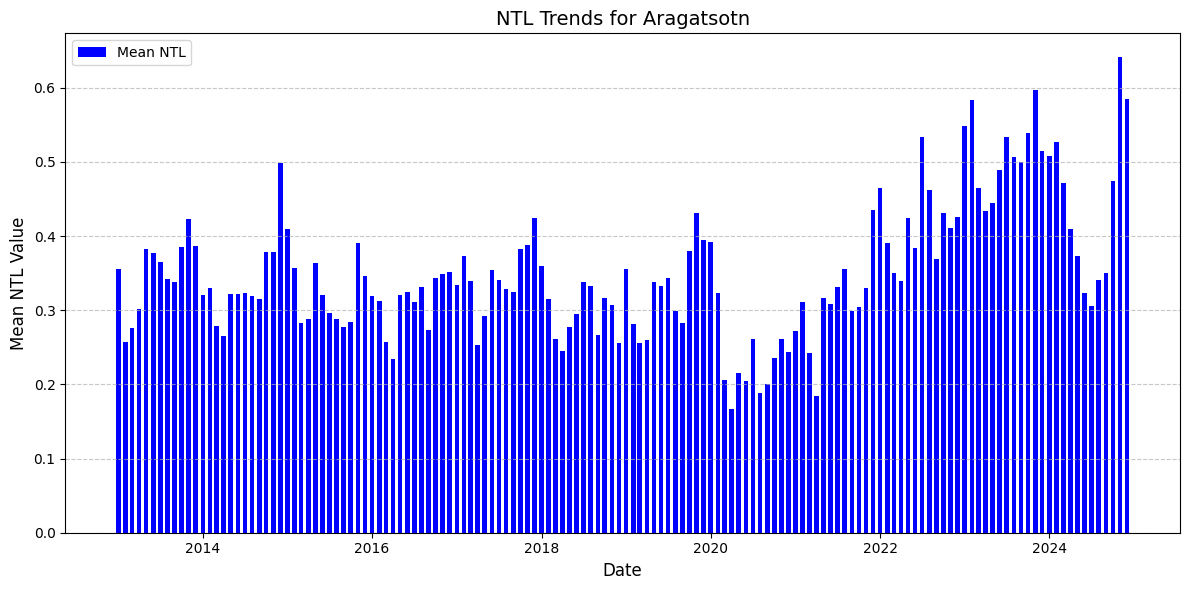

Processing NTL data for Admin 1: Ararat
Saved data for Ararat to NTL_Ararat.csv


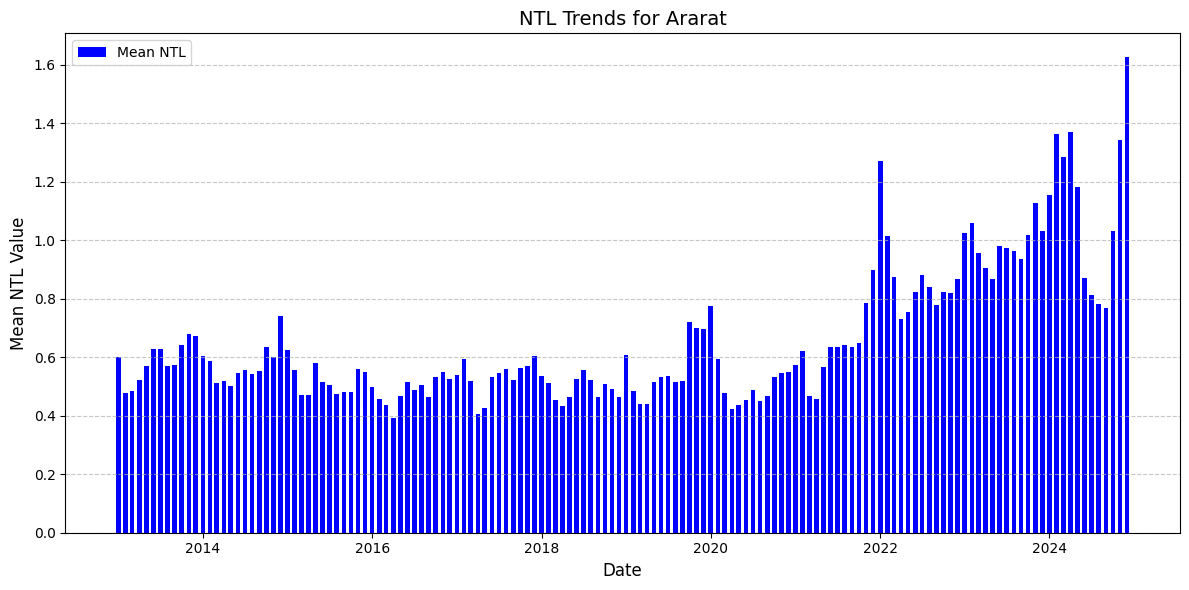

Processing NTL data for Admin 1: Armavir
Saved data for Armavir to NTL_Armavir.csv


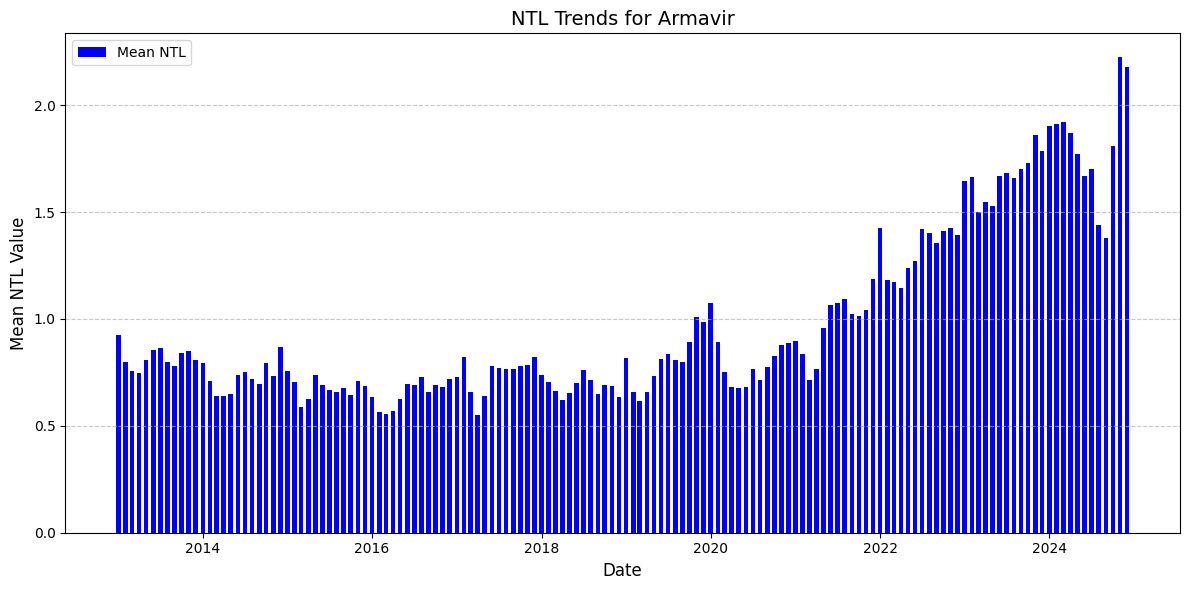

Processing NTL data for Admin 1: Erevan
Saved data for Erevan to NTL_Erevan.csv


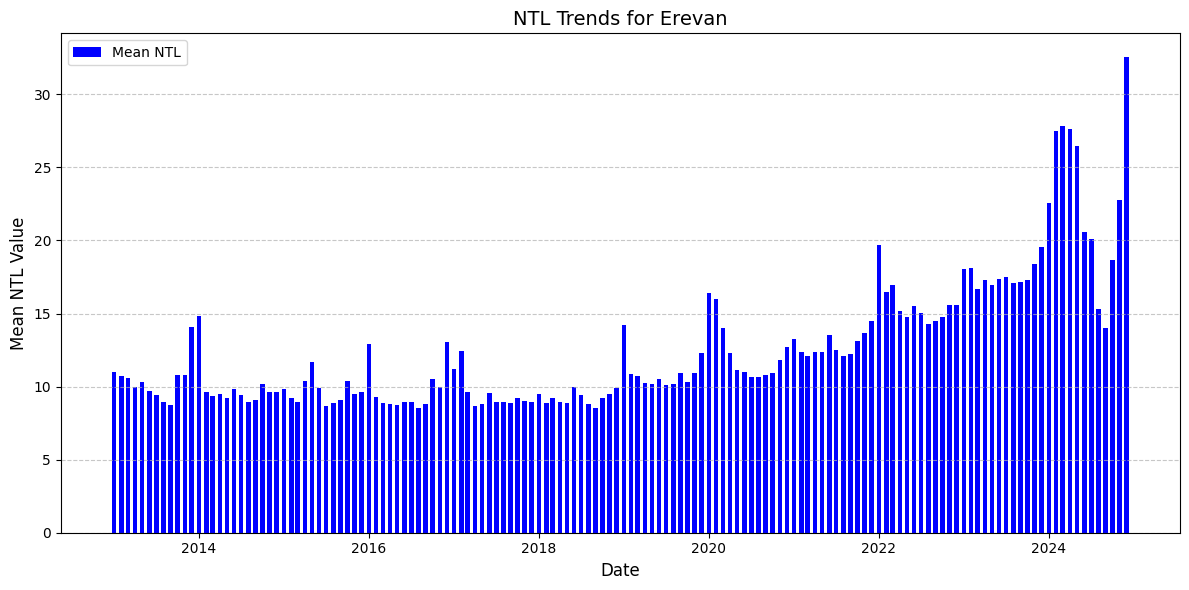

Processing NTL data for Admin 1: Gegharkunik
Saved data for Gegharkunik to NTL_Gegharkunik.csv


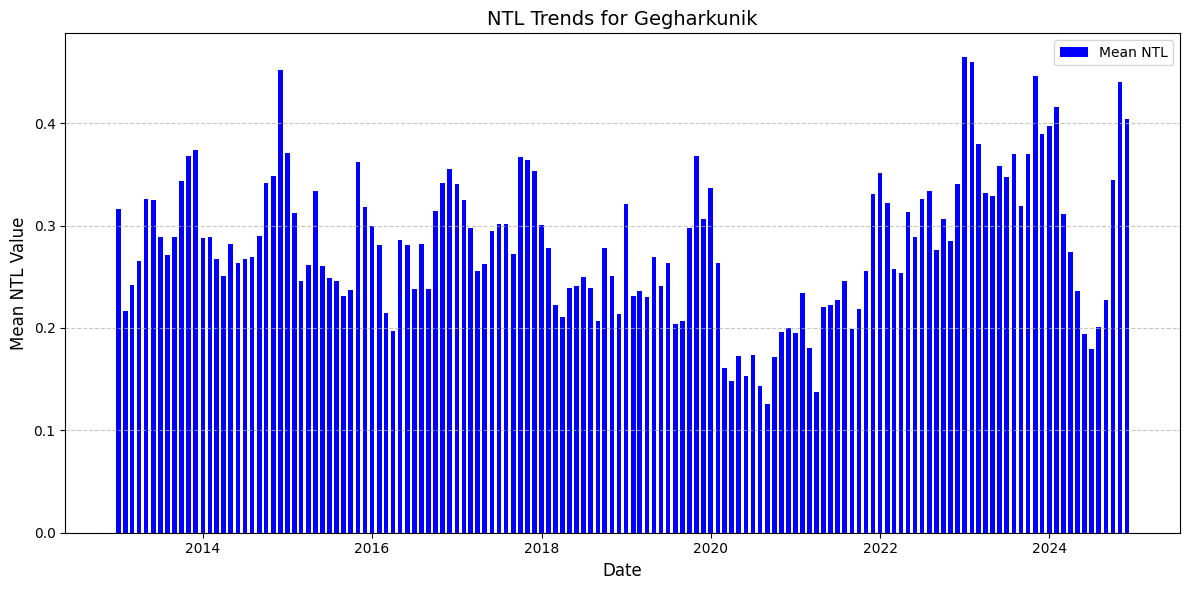

Processing NTL data for Admin 1: Kotayk
Saved data for Kotayk to NTL_Kotayk.csv


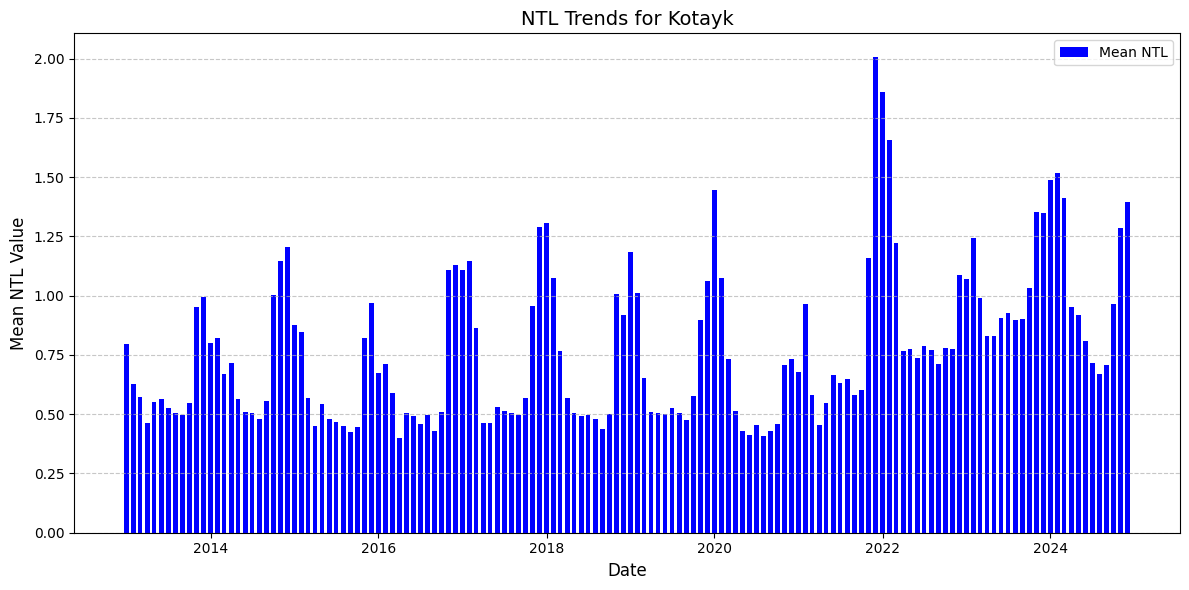

Processing NTL data for Admin 1: Lori
Saved data for Lori to NTL_Lori.csv


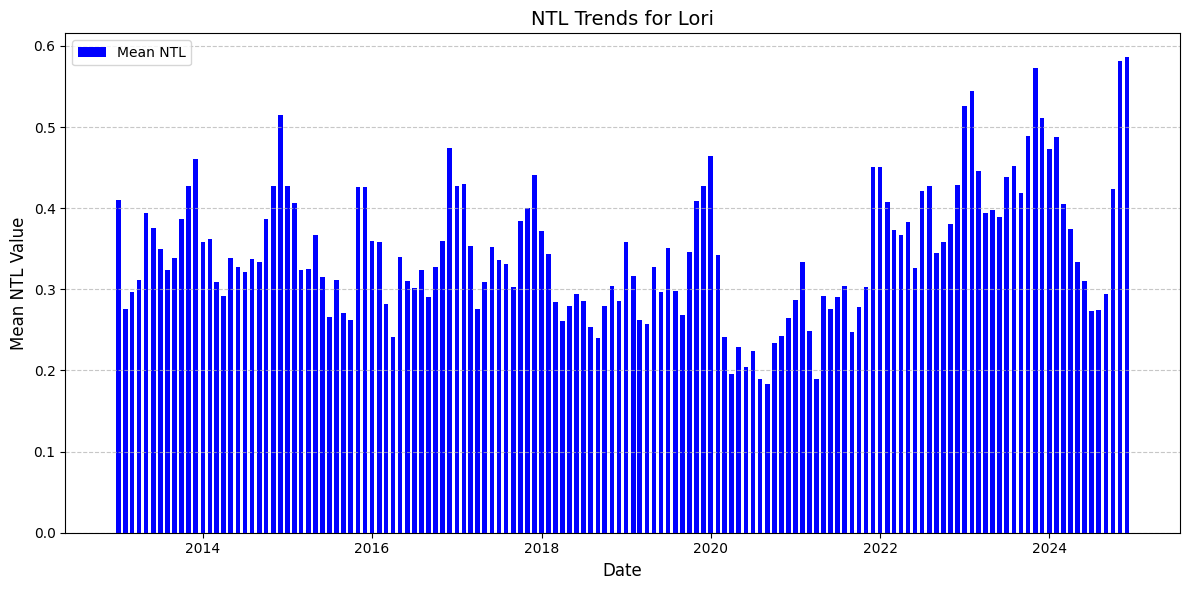

Processing NTL data for Admin 1: Shirak
Saved data for Shirak to NTL_Shirak.csv


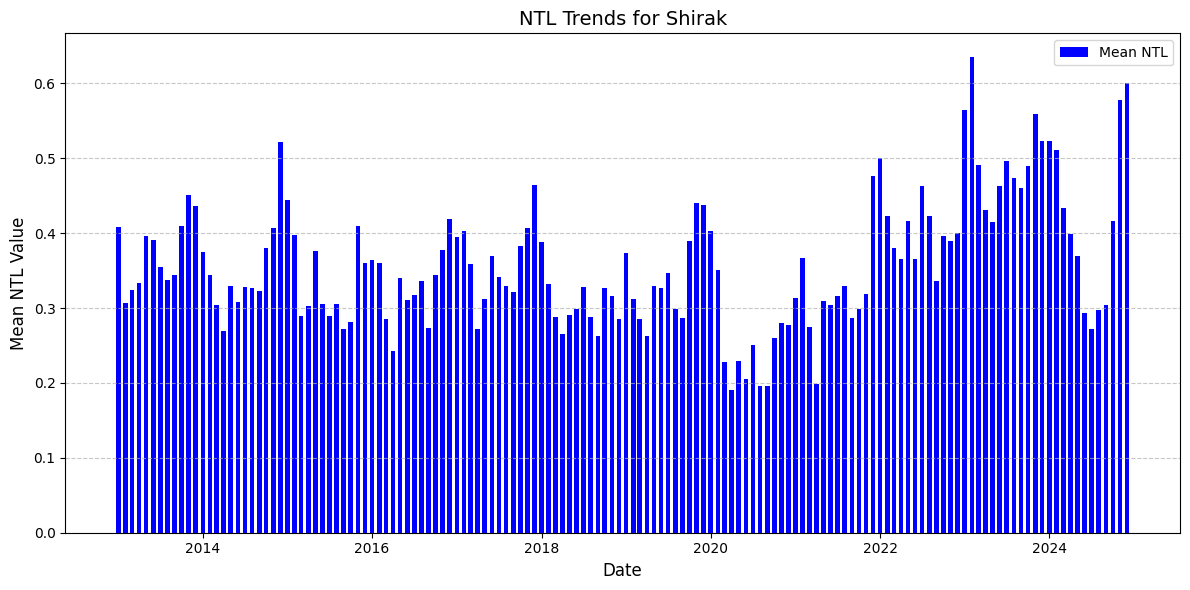

Processing NTL data for Admin 1: Syunik
Saved data for Syunik to NTL_Syunik.csv


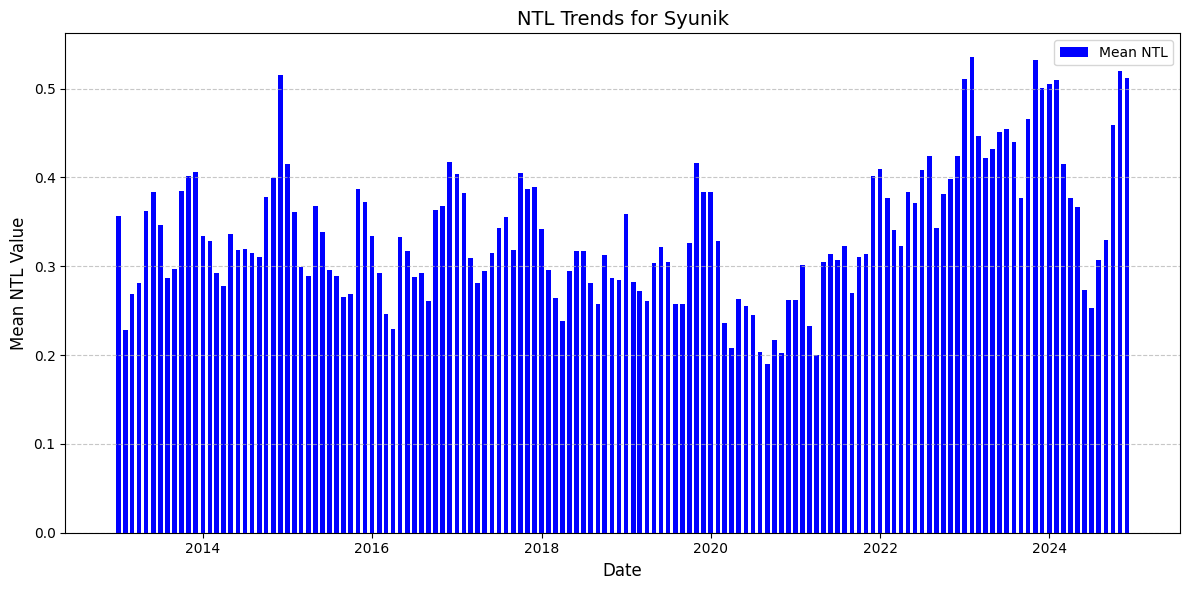

Processing NTL data for Admin 1: Tavush
Saved data for Tavush to NTL_Tavush.csv


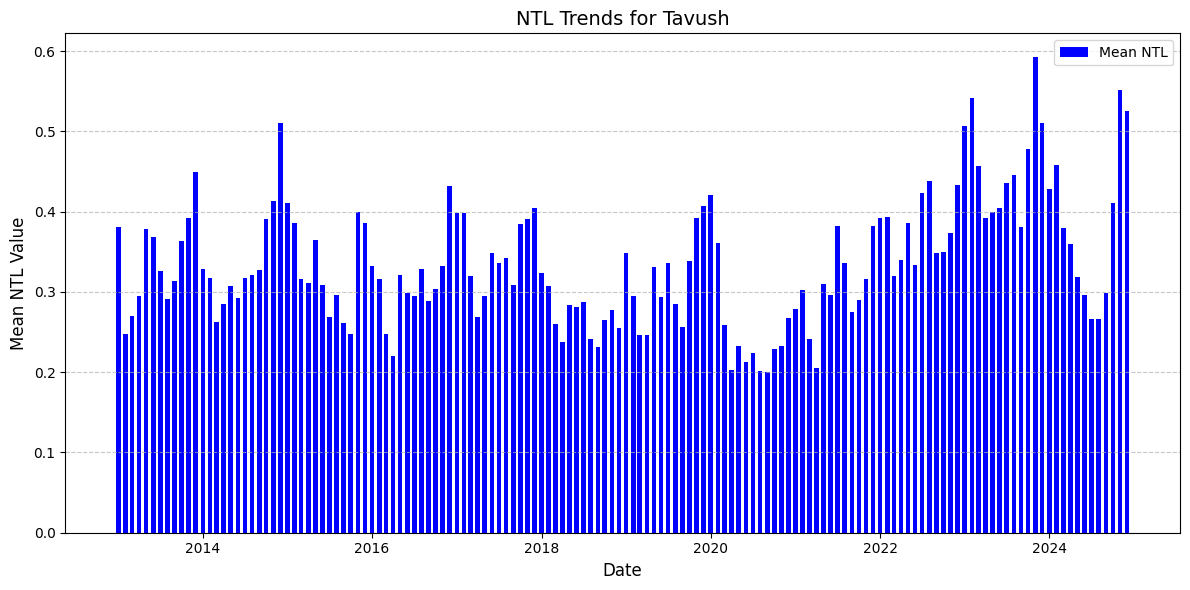

Processing NTL data for Admin 1: VayotsDzor
Saved data for VayotsDzor to NTL_VayotsDzor.csv


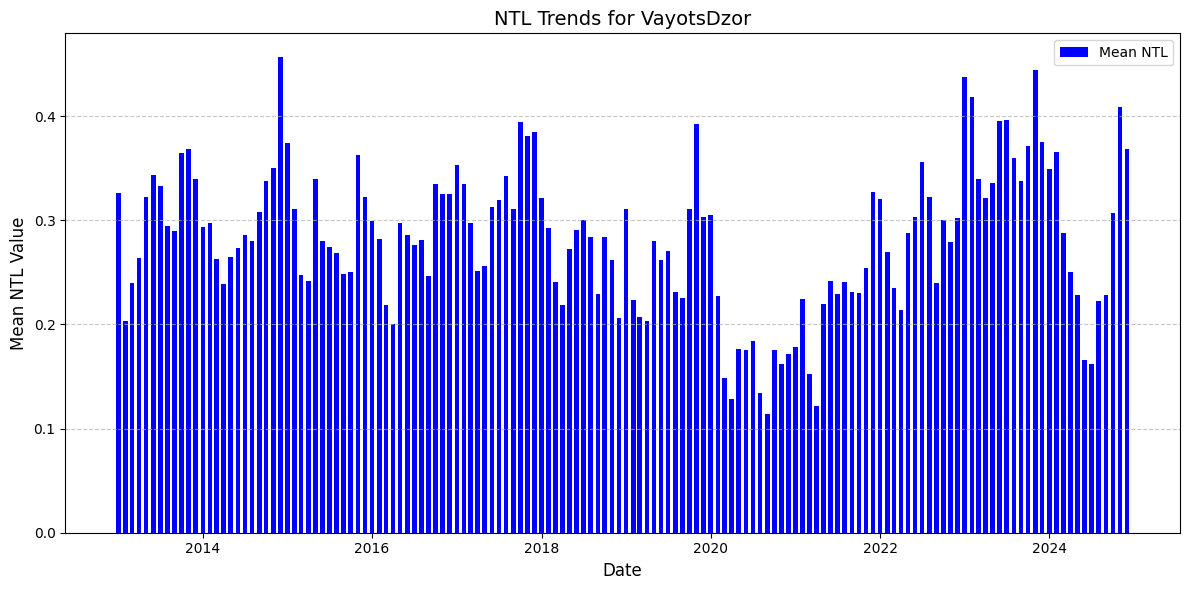

In [ ]:
# Define start and end dates
start_date = "2013-01-01"
end_date = "2024-12-31"

# Create a DataFrame for each Admin 1 region
dates = pd.date_range(start=start_date, end=end_date, freq='MS')
for region in regions:
    # Use 'NAME_1' for Admin 1 name in GADM data
    region_name = region['properties']['NAME_1']
    print(f"Processing NTL data for Admin 1: {region_name}")

    geometry = ee.Geometry(region['geometry'])

    # DataFrame to store NTL data
    df = pd.DataFrame({'Date': dates})
    df['Year'] = df['Date'].dt.year
    df['Month'] = df['Date'].dt.month
    df['Mean_avg_rad'] = pd.NA
    df['Sum_avg_rad'] = pd.NA

    # Fetch NTL data for each month
    for index, row in df.iterrows():
        try:
            date = row['Date']
            mean_NTL, sum_NTL = get_NTL_for_date(date, geometry, NTL_dataset)
            df.at[index, 'Mean_avg_rad'] = mean_NTL
            df.at[index, 'Sum_avg_rad'] = sum_NTL
        except Exception as e:
            print(f"Error for {region_name} on {date}: {e}")

    # Save to CSV
    output_file = f"NTL_{region_name.replace(' ', '_')}.csv"
    df.to_csv(output_file, index=False)
    print(f"Saved data for {region_name} to {output_file}")

    # Filter out rows with NA values before plotting
    df_filtered = df.dropna(subset=['Mean_avg_rad'])

    # Plot the data as bar charts
    plt.figure(figsize=(12, 6))
    plt.bar(df_filtered['Date'], df_filtered['Mean_avg_rad'], label='Mean NTL', color='blue', width=20)  # Adjust width as needed

    # Add labels and titles
    plt.title(f"NTL Trends for {region_name}", fontsize=14)
    plt.xlabel("Date", fontsize=12)
    plt.ylabel("Mean NTL Value", fontsize=12)
    plt.legend()
    plt.grid(axis='y', linestyle='--', alpha=0.7)  # Add grid lines for clarity
    plt.tight_layout()

    # Save the plot as an image and display it
    plt.savefig(f"NTL_Trends_{region_name.replace(' ', '_')}.png")  # Save the plot as an image
    plt.show()

The following organizes these PNG images into a grid layout, displaying up to three charts per row. Each chart represents an Admin 1 region, with titles indicating the region names

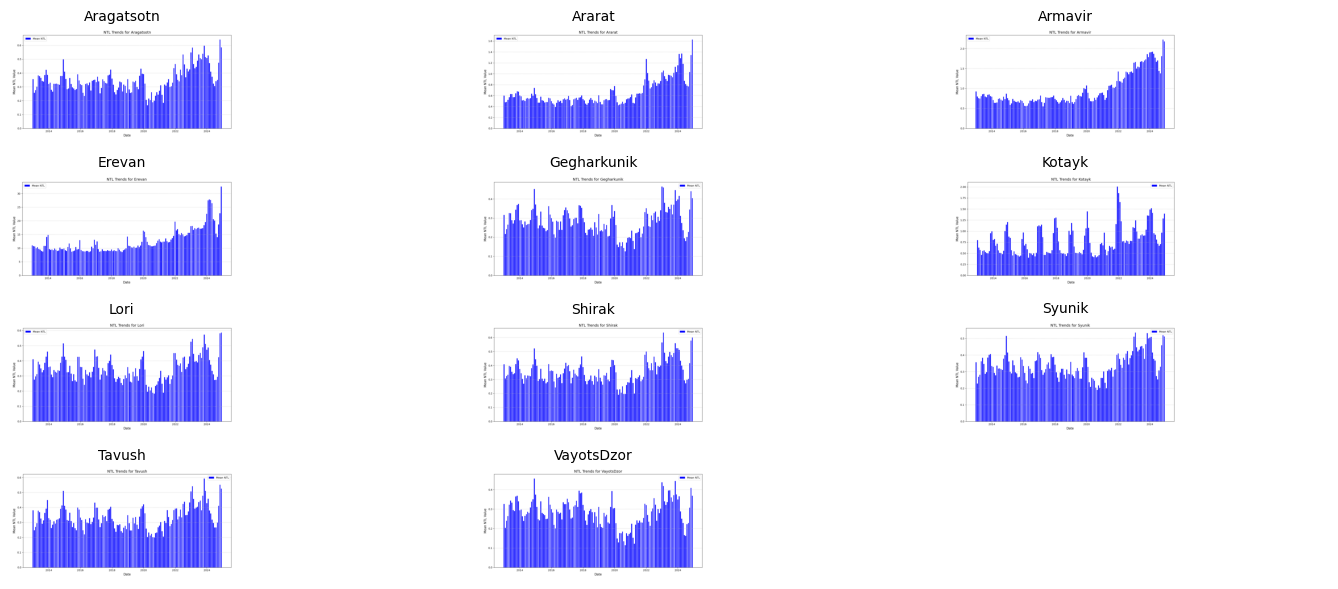

In [ ]:
# Stack the PNG images side by side
image_paths = [f"NTL_Trends_{region['properties']['NAME_1'].replace(' ', '_')}.png" for region in regions]

# Filter out image paths that do not exist
existing_image_paths = [img_path for img_path in image_paths if os.path.exists(img_path)]

# If no images are available, show a message
if not existing_image_paths:
    print("No images found.")
else:
    # Load images into matplotlib
    images = [mpimg.imread(img_path) for img_path in existing_image_paths]

    # Number of images per row (3 images per row)
    ncols = 3
    nrows = (len(images) + ncols - 1) // ncols  # Calculate the required number of rows

    # Create a figure with subplots, arranging images 3 in a row
    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(15, 6))

    # Flatten axes array in case of multiple rows
    axes = axes.flatten()

    # Zip the axes, images, and regions together, but only for the existing images
    for ax, img, img_path in zip(axes, images, existing_image_paths):
        ax.imshow(img)
        ax.axis('off')  # Hide axes

        # Get the region name from the image file name
        region_name = img_path.replace("NTL_Trends_", "").replace(".png", "").replace("_", " ")
        ax.set_title(f"{region_name}", fontsize=10)

    # If there are any unused axes (in case the number of images isn't a multiple of 3), hide them
    for i in range(len(images), len(axes)):
        axes[i].axis('off')

    # Adjust layout and display
    plt.tight_layout()
    plt.show()
